# Layer 2: Earnings Call Guidance Sentiment

## Introduction

Layer 1 left the question of "Does the alt data actually lack signal, or
was a 98-row, 9-feature GBM simply the wrong amount of complexity for the
data available?" This notebook adds one more feature, guidance sentiment
from Samsung Electronics' quarterly earnings conference calls, and
reruns the same GBM versus Ridge comparison to see whether it moves
either model, in either direction.

Source: Samsung's English-language conference call decks, published
quarterly on samsung.com/global/ir. These are first-party, public
documents, and no login or API key is required. 33 quarters, 2018 Q1
through 2026 Q2, were downloaded and parsed with `pypdf`.

Scoring: the Loughran-McDonald financial sentiment dictionary, via
`pysentiment2`, rather than a generic sentiment model. LM was built
specifically for filing and earnings language, where words like
"impairment" or "headwind" carry real negative weight that a
general-purpose sentiment model tends to score as neutral.

Scope limitation, stated plainly: SK Hynix and Hyundai are not included.
Neither exposes the kind of predictable, scrapeable PDF archive
Samsung's IR site does, and DART's OpenDART API needs a manually
registered key, the same constraint as the Customs flash export data in
Layer 1. See `src/customs_flash.py`. Samsung alone is a reasonable first
pass given its share of Korea's semiconductor exports, but it is one
company's sentiment, not sector-wide sentiment, and that gap matters
more the more weight this feature ends up carrying.


In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import shap

from layer2_model import build_dataset
from layer1_model import make_gbm_forecaster, make_ridge_forecaster, fit_full_model
from walk_forward import walk_forward_x, rmse, mape
from earnings_sentiment import build_sentiment_series

plt.rcParams["figure.figsize"] = (11, 4)

C:\qrvenv_work\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Methodology

Preventing Look Ahead, each quarter's call is only treated as known starting the
month after Samsung's approximate release month. Q1 becomes available in
May, Q2 in August, Q3 in November, Q4 in February. This is a
deliberately conservative buffer, since exact release dates within the
month were not independently verified.

Everything else is identical to Layer 1, same GBM and Ridge pair, same
36-month rolling-origin walk-forward, same `target_lag1` and
`target_lag12` features. The only change is one added column, so any
shift in the numbers below is attributable to sentiment specifically.

Adding the sentiment feature costs 2 rows relative to Layer 1, 96 versus
98, since Samsung's earliest usable call pushes the start date slightly
later once the one-month availability buffer is applied.

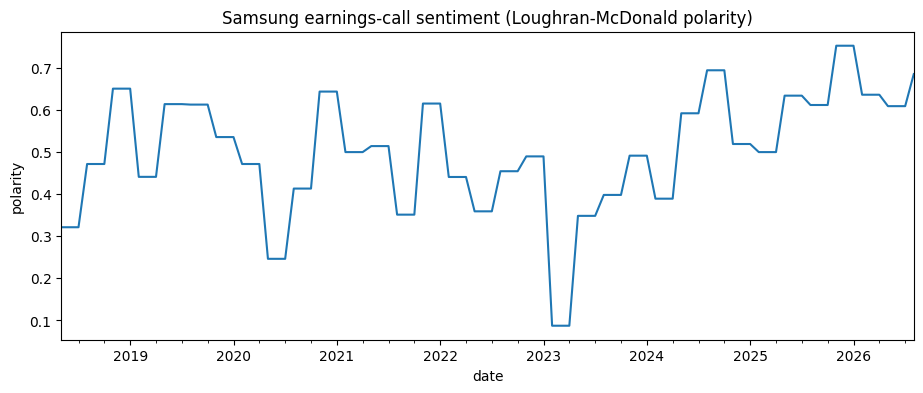

96 rows, 10 features, 2018-05-01 to 2026-04-01


In [2]:
sentiment = build_sentiment_series()
fig, ax = plt.subplots()
sentiment.plot(ax=ax)
ax.set_title("Samsung earnings-call sentiment (Loughran-McDonald polarity)")
ax.set_ylabel("polarity")
plt.show()

y, X = build_dataset()
print(f"{len(y)} rows, {X.shape[1]} features, {y.index.min().date()} to {y.index.max().date()}")

In [3]:
N_TEST = 36

models = {
    "gbm": make_gbm_forecaster(),
    "ridge": make_ridge_forecaster(alpha=10.0),
}

results = {name: walk_forward_x(y, X, fn, n_test=N_TEST) for name, fn in models.items()}

for name, df in results.items():
    print(f"{name:>18}  RMSE={rmse(df):>14,.0f}  MAPE={mape(df):>6.2f}%")

print()
print("Reference, same 36-month window:")
print(f"{'naive (L0)':>18}  RMSE={2_847_251_652:>14,.0f}  MAPE={3.14:>6.2f}%")
print(f"{'sarima (L0)':>18}  RMSE={2_881_346_571:>14,.0f}  MAPE={2.92:>6.2f}%")
print(f"{'gbm (L1)':>18}  RMSE={4_661_166_131:>14,.0f}  MAPE={4.92:>6.2f}%")
print(f"{'ridge (L1)':>18}  RMSE={3_281_969_926:>14,.0f}  MAPE={3.30:>6.2f}%")

               gbm  RMSE= 4,746,560,993  MAPE=  4.93%
             ridge  RMSE= 3,192,621,761  MAPE=  3.26%

Reference, same 36-month window:
        naive (L0)  RMSE= 2,847,251,652  MAPE=  3.14%
       sarima (L0)  RMSE= 2,881,346,571  MAPE=  2.92%
          gbm (L1)  RMSE= 4,661,166,131  MAPE=  4.92%
        ridge (L1)  RMSE= 3,281,969,926  MAPE=  3.30%


## Interpretability: where does sentiment rank?

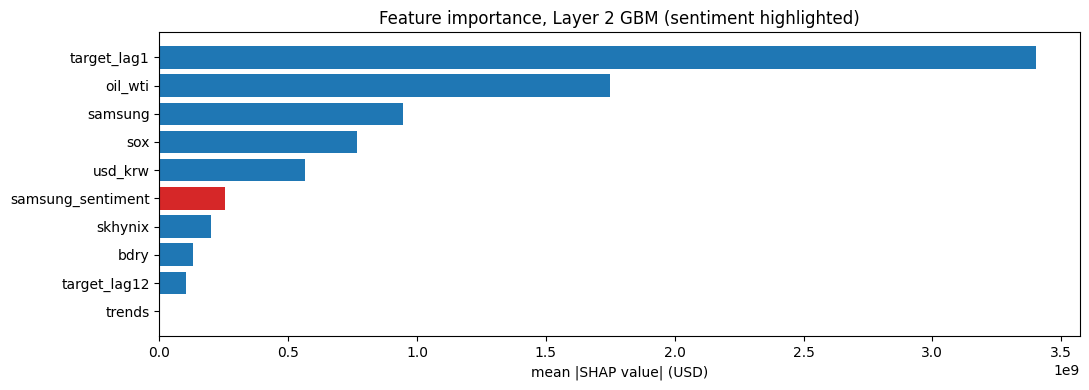

In [4]:
model = fit_full_model(y, X)
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

mean_abs = np.abs(shap_values.values).mean(axis=0)
order = np.argsort(mean_abs)[::-1]

fig, ax = plt.subplots()
colors = ["#d62728" if X.columns[i] == "samsung_sentiment" else "#1f77b4" for i in order]
ax.barh([X.columns[i] for i in order][::-1], mean_abs[order][::-1], color=colors[::-1])
ax.set_xlabel("mean |SHAP value| (USD)")
ax.set_title("Feature importance, Layer 2 GBM (sentiment highlighted)")
plt.tight_layout()
plt.show()

## Findings

Ridge improved slightly, MAPE from 3.30% to 3.26%, RMSE from 3.28B to
3.19B. Small, but it is the first result to move in the right
direction after adding a feature.

GBM got slightly worse, MAPE from 4.92% to 4.93%. Consistent with
the Layer 1 finding that GBM is already past its complexity budget for
roughly 96 to 98 rows. One more feature is one more way to overfit, not
one more chance to find signal.

Neither model beats Layer 0 yet, where naive sits at MAPE 3.14% and
SARIMA at 2.92%. Sentiment is a real, plausible feature and not noise,
based on where it lands in the SHAP ranking, but it is not the thing
that closes the gap to the baseline on its own.

SHAP ranks sentiment mid-pack: below the AR term, oil, Samsung's own
stock price, and SOX, but above SK Hynix, BDRY, and `target_lag12`. That
is a believable place for a single company's guidance tone to land as a real but not dominant signal.

## Key takeaways

The Ridge versus GBM gap that showed up in Layer 1 held again here. It
is still sample size limiting the flexible model more than feature
relevance limiting the data. That pattern across two independent layers
is worth taking seriously going into the capstone surface.

Sentiment is the first feature across Layers 1 and 2 to make the
regularized model modestly better, not just the SHAP ranking better.
That is a meaningfully stronger bar than SHAP saying it is not zero, and
it clears it.

The Samsung-only scope is a limitation, not a formality. A
sector-wide sentiment signal covering Samsung, SK Hynix, and Hyundai
would be a fairer test of the earnings sentiment idea than one company's
guidance tone. Worth returning to if there is time.